In [1]:
#Load Dataset
import pandas as pd
df = pd.read_csv('/kaggle/input/supermarket-eda/supermarket.csv')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
#Handling datetime datatype
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True)

In [4]:
df['Order Month'] = df['Order Date'].dt.month
df['Ship Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

In [5]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Month,Ship Duration
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,11,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,11,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,6,4


In [6]:
#Handling Duplicates
df.duplicated().sum()

np.int64(0)

No duplicates

In [7]:
#Handling missing values
round(df.isnull().mean()*100,2)

Row ID           0.00
Order ID         0.00
Order Date       0.00
Ship Date        0.00
Ship Mode        0.00
Customer ID      0.00
Customer Name    0.00
Segment          0.00
Country          0.00
City             0.00
State            0.00
Postal Code      0.11
Region           0.00
Product ID       0.00
Category         0.00
Sub-Category     0.00
Product Name     0.00
Sales            0.00
Order Month      0.00
Ship Duration    0.00
dtype: float64

In [8]:
df.fillna({'Postal Code': df['Postal Code'].median()}, inplace=True)

In [9]:
#convert to int for postal code
df['Postal Code'] = df['Postal Code'].astype(int)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   int64         
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [11]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Month,Ship Duration
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,11,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,11,3


In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order Month', 'Ship Duration'],
      dtype='object')

In [13]:
#Feature Selection
ml_df=df[['Ship Mode','Segment','City','State',
       'Postal Code','Region','Category','Sub-Category',
       'Sales','Order Month','Ship Duration']]

In [14]:
ml_df.head(3)

,Ship Mode,Segment,City,State,Postal Code,Region,Category,Sub-Category,Sales,Order Month,Ship Duration
0,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,11,3
1,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,11,3
2,Second Class,Corporate,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,6,4


In [15]:
num_cols = ml_df.select_dtypes(include='number').columns
cat_cols = ml_df.select_dtypes(exclude='number').columns
print('Numerical columns: ',num_cols)
print('Categorical columns: ',cat_cols)

Numerical columns:  Index(['Postal Code', 'Sales', 'Order Month', 'Ship Duration'], dtype='object')
Categorical columns:  Index(['Ship Mode', 'Segment', 'City', 'State', 'Region', 'Category',
       'Sub-Category'],
      dtype='object')


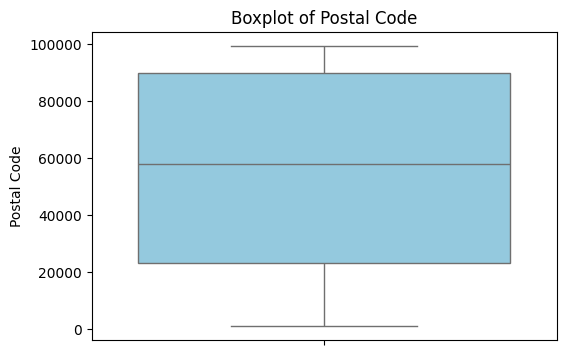

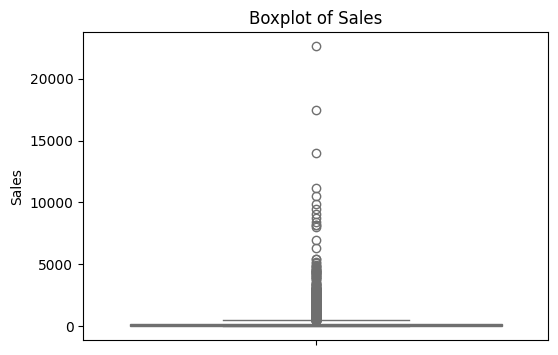

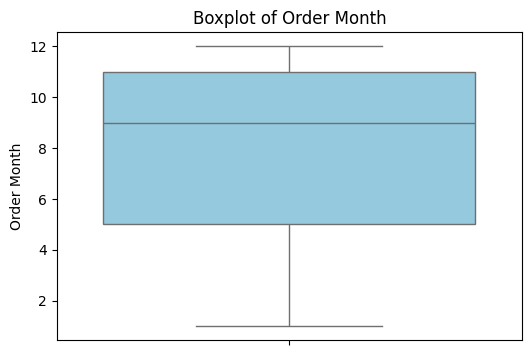

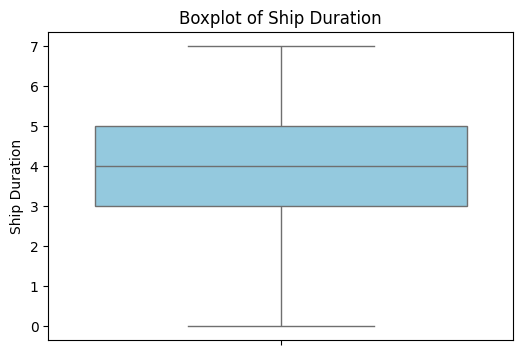

In [16]:
#Data Visualization for outlier detection
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=ml_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

Sales column has got outliers

In [17]:
def cap_outliers_numeric(df, numeric_cols):
    """
    Caps outliers in all numeric columns using 1.5*IQR method.
    Modifies the DataFrame in-place to avoid SettingWithCopyWarning.
    """
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Use .loc to modify safely
        df.loc[:, col] = df[col].clip(lower_limit, upper_limit)

In [18]:
cap_outliers_numeric(ml_df, num_cols)

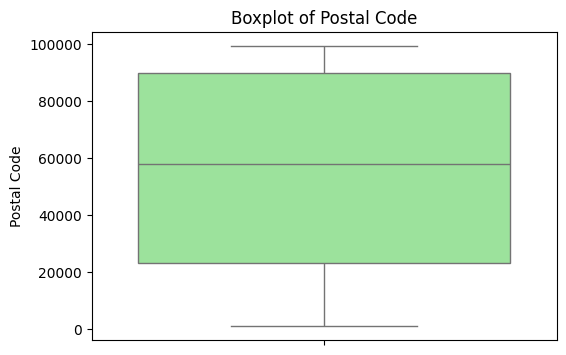

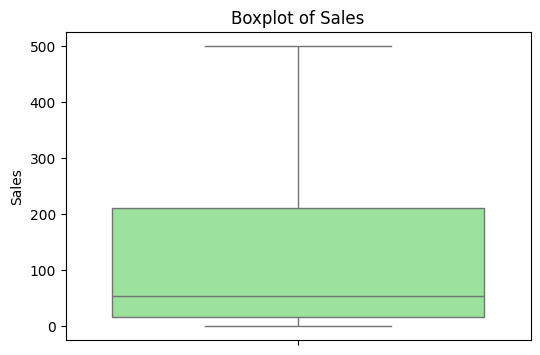

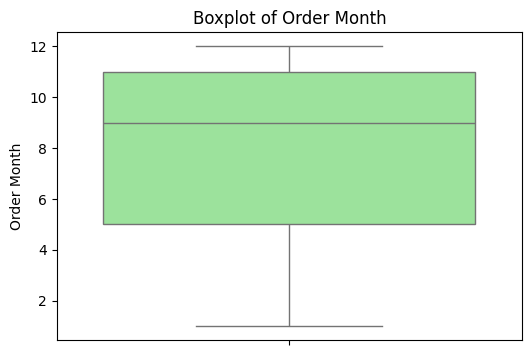

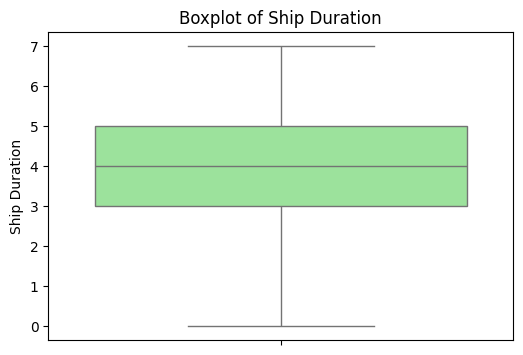

In [19]:
# Boxplots (to check outliers)
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=ml_df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [20]:
#Skewness Detection
for col in num_cols:
    print(col, ":", ml_df[col].skew())

Postal Code : -0.1316633565215324
Sales : 1.2177552186803569
Order Month : -0.4319882024106119
Ship Duration : -0.4273575345243775


We need to treat the skewness for Sales

In [21]:
import numpy as np
ml_df['Sales'] = np.sqrt(ml_df['Sales'])

/tmp/ipykernel_16/61389907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_df['Sales'] = np.sqrt(ml_df['Sales'])


In [22]:
for col in num_cols:
    print(col, ":", ml_df[col].skew())

Postal Code : -0.1316633565215324
Sales : 0.7349797033950897
Order Month : -0.4319882024106119
Ship Duration : -0.4273575345243775


In [23]:
ml_df[cat_cols]

,Ship Mode,Segment,City,State,Region,Category,Sub-Category
0,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs
2,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels
3,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage
...,...,...,...,...,...,...,...
9795,Standard Class,Corporate,Chicago,Illinois,Central,Office Supplies,Binders
9796,Standard Class,Corporate,Toledo,Ohio,East,Office Supplies,Art
9797,Standard Class,Corporate,Toledo,Ohio,East,Technology,Phones
9798,Standard Class,Corporate,Toledo,Ohio,East,Technology,Phones


In [24]:
ml_df['Segment'].value_counts()

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

In [25]:
#One-hot encoding for categorical columns
one_hot_cols = ['Ship Mode','Segment','Region','Category']

ml_df = pd.get_dummies(
    ml_df,
    columns=one_hot_cols,
    drop_first=True, dtype=int
)

In [26]:
#Target encoding for high cardinality categorical column
city_target_mean = ml_df.groupby('City')['Sales'].mean() 
ml_df['City'] = ml_df['City'].map(city_target_mean)

state_target_mean = ml_df.groupby('State')['Sales'].mean() 
ml_df['State'] = ml_df['State'].map(state_target_mean)

sub_target_mean = ml_df.groupby('Sub-Category')['Sales'].mean() 
ml_df['Sub-Category'] = ml_df['Sub-Category'].map(sub_target_mean)

In [27]:
ml_df.head(3)

,City,State,Postal Code,Sub-Category,Sales,Order Month,Ship Duration,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology
0,11.090152,10.803328,42420,17.150354,16.185178,11,3,0,1,0,0,0,0,1,0,0,0
1,11.090152,10.803328,42420,17.604291,22.374997,11,3,0,1,0,0,0,0,1,0,0,0
2,10.389837,10.114294,90036,4.783858,3.823611,6,4,0,1,0,1,0,0,0,1,1,0


In [28]:
ml_df.describe()

,City,State,Postal Code,Sub-Category,Sales,Order Month,Ship Duration,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology
count,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,9.749220,9.749220,55276.498571,9.749220,9.749220,7.818469,3.961122,0.054898,0.194082,0.597857,0.301327,0.178163,0.284184,0.163061,0.320408,0.602959,0.185000
std,1.730505,0.821329,32023.374393,4.511735,6.765587,3.281905,1.749614,0.227793,0.395512,0.490355,0.458858,0.382670,0.451048,0.369440,0.466657,0.489310,0.388317
min,1.179830,7.567947,1040.000000,3.458408,0.666333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.850241,8.937506,23223.000000,6.175232,4.153071,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.913178,10.114294,58103.000000,7.996381,7.381734,9.000000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,10.389837,10.246022,90008.000000,12.398707,14.512236,11.000000,5.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,22.374997,22.374997,99301.000000,22.138556,22.374997,12.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
ml_df.columns

Index(['City', 'State', 'Postal Code', 'Sub-Category', 'Sales', 'Order Month',
       'Ship Duration', 'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office',
       'Region_East', 'Region_South', 'Region_West',
       'Category_Office Supplies', 'Category_Technology'],
      dtype='object')

In [30]:
#Scaling
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'City', 
    'State', 
    'Postal Code', 
    'Sub-Category', 
    'Sales', 
    'Order Month',
    'Ship Duration', 
]
scaler = StandardScaler()
ml_df[scale_cols] = scaler.fit_transform(ml_df[scale_cols])

In [31]:
ml_df.head(3)

,City,State,Postal Code,Sub-Category,Sales,Order Month,Ship Duration,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology
0,0.774919,1.283483,-0.401493,1.640502,0.951327,0.969465,-0.549362,0,1,0,0,0,0,1,0,0,0
1,0.774919,1.283483,-0.401493,1.741120,1.866271,0.969465,-0.549362,0,1,0,0,0,0,1,0,0,0
2,0.370210,0.444514,1.085497,-1.100600,-0.875890,-0.554118,0.022222,0,1,0,1,0,0,0,1,1,0


Final processed data for ML

Elbow method to find optimal clusters

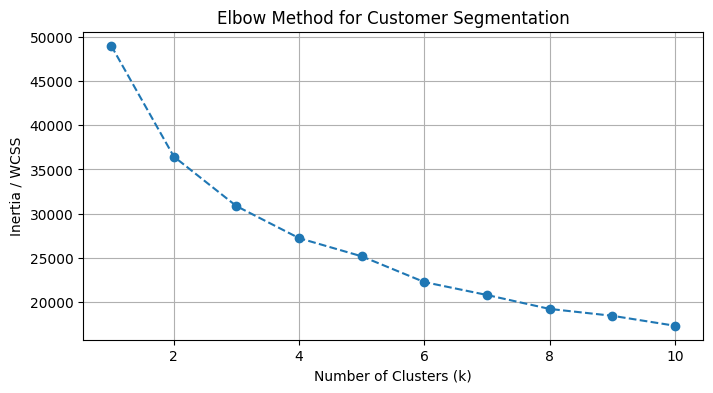

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Features for customer segmentation: Sales, Ship Duration, Sub-Category, Region
clustering_cols = ['Sales', 'Ship Duration', 'Sub-Category', 'Postal Code', 'Order Month']
X_cluster = ml_df[clustering_cols]

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Customer Segmentation')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / WCSS')
plt.grid(True)
plt.show()

fit k-means and Assign Customer Segments

In [33]:
# Optimal clusters based on elbow curve (e.g., k=3 or k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
ml_df['Customer_Cluster'] = kmeans.fit_predict(X_cluster)

# Segment profiling
cluster_summary = ml_df.groupby('Customer_Cluster')[['Sales', 'Ship Duration', 'Sub-Category']].mean()
print("Cluster Summary (Normalized Insights):\n", cluster_summary)

Cluster Summary (Normalized Insights):
                      Sales  Ship Duration  Sub-Category
Customer_Cluster                                       
0                -0.516942      -0.042159     -0.470578
1                -0.472702       0.055531     -0.460853
2                -0.461836       0.016117     -0.425160
3                 1.338295      -0.026489      1.251334
